## VOD Analysis: Dry vs Wet

__Author:__ German Vargas G.

__Date:__ Oct - 23 - 2025

### Load Libraries

In [23]:
import gnssvod as gv
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib.collections import PatchCollection
import matplotlib.dates as mdates

### Pair data forest and sky data

Open the dataset you want to plot SNR. Do it by period, so it can be visualized dry season versus wet season. Do separate folders for each forest cover

In [24]:
import os

# Define base paths for each location
# Define the base path to the nc files based on the user's home directory and the relative path to the nc files
base_path = os.path.join(os.path.expanduser('~'), 'Library/CloudStorage/Box-Box/Project_HorizontesGNSS/Data/nc_files')

# Define patterns for dry and wet seasons for each location
pattern_dry = {
    'SWIMAC': f"{base_path}/SWIMAC/DrySeason/*.nc",
    'PACQUI': f"{base_path}/PACQUI/DrySeason/*.nc",
    'MANCHI': f"{base_path}/MANCHI/DrySeason/*.nc",
    'MetSta': f"{base_path}/MetSta/DrySeason/*.nc"
}

pattern_wet = {
    'SWIMAC': f"{base_path}/SWIMAC/WetSeason/*.nc",
    'PACQUI': f"{base_path}/PACQUI/WetSeason/*.nc",
    'MANCHI': f"{base_path}/MANCHI/WetSeason/*.nc",
    'MetSta': f"{base_path}/MetSta/WetSeason/*.nc"
}

# Define time intervals for dry and wet seasons
startday_DrySeason = pd.to_datetime('15-04-2025', format='%d-%m-%Y')
startday_WetSeason = pd.to_datetime('12-08-2025', format='%d-%m-%Y')

timeintervals_DrySeason = pd.interval_range(start=startday_DrySeason, periods=10, freq='D', closed='left')
timeintervals_WetSeason = pd.interval_range(start=startday_WetSeason, periods=10, freq='D', closed='left')

# Define pairings (MetSta as reference with each forest site)
pairings = {
    'SWIMAC_pair': ('MetSta', 'SWIMAC'),
    'PACQUI_pair': ('MetSta', 'PACQUI'),
    'MANCHI_pair': ('MetSta', 'MANCHI')
}

# Define output directories for each pairing with season-specific subdirectories
outputdir_dry = {
    'SWIMAC_pair': f"{base_path}/SWIMAC/Paired/DrySeason",
    'PACQUI_pair': f"{base_path}/PACQUI/Paired/DrySeason",
    'MANCHI_pair': f"{base_path}/MANCHI/Paired/DrySeason"
}

outputdir_wet = {
    'SWIMAC_pair': f"{base_path}/SWIMAC/Paired/WetSeason",
    'PACQUI_pair': f"{base_path}/PACQUI/Paired/WetSeason",
    'MANCHI_pair': f"{base_path}/MANCHI/Paired/WetSeason"
}

# Define variables to keep
keepvars = ['S*', 'Azimuth', 'Elevation']

# Process Dry Season
print("Processing Dry Season data...")
out_dry = gv.gather_stations(pattern_dry, pairings, timeintervals_DrySeason, 
                           keepvars=keepvars, outputdir=outputdir_dry)

# Process Wet Season
print("Processing Wet Season data...")
out_wet = gv.gather_stations(pattern_wet, pairings, timeintervals_WetSeason, 
                           keepvars=keepvars, outputdir=outputdir_wet)

Processing Dry Season data...
Extracting Epochs from files
----- Processing SWIMAC_pair
-- Processing interval [2025-04-15 00:00:00, 2025-04-16 00:00:00)
Found 1 file(s) for MetSta
Reading
Found 1 file(s) for SWIMAC
Reading
Concatenating stations
Saving result in /Users/ger/Library/CloudStorage/Box-Box/Project_HorizontesGNSS/Data/nc_files/SWIMAC/Paired/DrySeason
Saved 18102 observations in SWIMAC_pair_20250415000000_20250416000000.nc
-- Processing interval [2025-04-16 00:00:00, 2025-04-17 00:00:00)
Found 2 file(s) for MetSta
Reading
Found 2 file(s) for SWIMAC
Reading
Concatenating stations
Saving result in /Users/ger/Library/CloudStorage/Box-Box/Project_HorizontesGNSS/Data/nc_files/SWIMAC/Paired/DrySeason
Saved 207027 observations in SWIMAC_pair_20250416000000_20250417000000.nc
-- Processing interval [2025-04-17 00:00:00, 2025-04-18 00:00:00)
Found 2 file(s) for MetSta
Reading
Found 2 file(s) for SWIMAC
Reading
Concatenating stations
Saving result in /Users/ger/Library/CloudStorage/Box

### Calculate VOD per season

Now we will get the VOD for each species for each season

#### Step 1: Load paired data and calculate VOD

In [25]:
import os

# Define base path
base_path = os.path.join(os.path.expanduser('~'), 'Library/CloudStorage/Box-Box/Project_HorizontesGNSS/Data/nc_files')

# Define patterns for each species and season
patterns = {
    'SWIMAC_dry': f"{base_path}/SWIMAC/Paired/DrySeason/*.nc",
    'SWIMAC_wet': f"{base_path}/SWIMAC/Paired/WetSeason/*.nc",
    'PACQUI_dry': f"{base_path}/PACQUI/Paired/DrySeason/*.nc",
    'PACQUI_wet': f"{base_path}/PACQUI/Paired/WetSeason/*.nc",
    'MANCHI_dry': f"{base_path}/MANCHI/Paired/DrySeason/*.nc",
    'MANCHI_wet': f"{base_path}/MANCHI/Paired/WetSeason/*.nc"
}

# Define pairings for each species (MetSta is always the reference station)
pairings = {
    'SWIMAC_dry': ('MetSta', 'SWIMAC'),
    'SWIMAC_wet': ('MetSta', 'SWIMAC'),
    'PACQUI_dry': ('MetSta', 'PACQUI'),
    'PACQUI_wet': ('MetSta', 'PACQUI'),
    'MANCHI_dry': ('MetSta', 'MANCHI'),
    'MANCHI_wet': ('MetSta', 'MANCHI')
}

# Define frequency bands to combine
bands = {'VOD1':['S1','S1X','S1C'],'VOD7':['S7','S7X','S7C']}

# Calculate VOD for each species and season
vod_results = {}

# Process each pattern and store results
for site_season, pattern in patterns.items():
    print(f"Processing {site_season}...")
    site_pairings = {site_season: pairings[site_season]}
    vod = gv.calc_vod(pattern, site_pairings, bands)
    vod_results[site_season] = vod[site_season]
    print(f"Columns in {site_season}: {vod[site_season].columns.tolist()}")

# Display summary of results
for site_season, vod_data in vod_results.items():
    print(f"\nSummary for {site_season}:")
    print(vod_data)

Processing SWIMAC_dry...
Columns in SWIMAC_dry: ['VOD1', 'VOD7', 'Azimuth', 'Elevation']
Processing SWIMAC_wet...
Columns in SWIMAC_wet: ['VOD1', 'VOD7', 'Azimuth', 'Elevation']
Processing PACQUI_dry...
Columns in PACQUI_dry: ['VOD1', 'VOD7', 'Azimuth', 'Elevation']
Processing PACQUI_wet...
Columns in PACQUI_wet: ['VOD1', 'VOD7', 'Azimuth', 'Elevation']
Processing MANCHI_dry...
Columns in MANCHI_dry: ['VOD1', 'VOD7', 'Azimuth', 'Elevation']
Processing MANCHI_wet...
Columns in MANCHI_wet: ['VOD1', 'VOD7', 'Azimuth', 'Elevation']

Summary for SWIMAC_dry:
                             VOD1  VOD7  Azimuth  Elevation
Epoch               SV                                     
2025-04-17 00:00:00 C11       NaN   NaN    -31.4       19.4
                    C12       NaN   NaN     -1.1       70.5
                    C14       NaN   NaN   -114.5       20.0
                    C21       NaN   NaN    -14.4       52.1
                    C22       NaN   NaN     31.3       15.0
...                  

#### Step 2: Hemispheric plot of VOD

Use the Hemi class to calculate and plot a gridded representation of VOD

Saved figure to: /Users/ger/Documents/github_repos/GNSS_ACG/PyNotebooks/figures/VOD_comparison_dry_wet_elevation_20.png


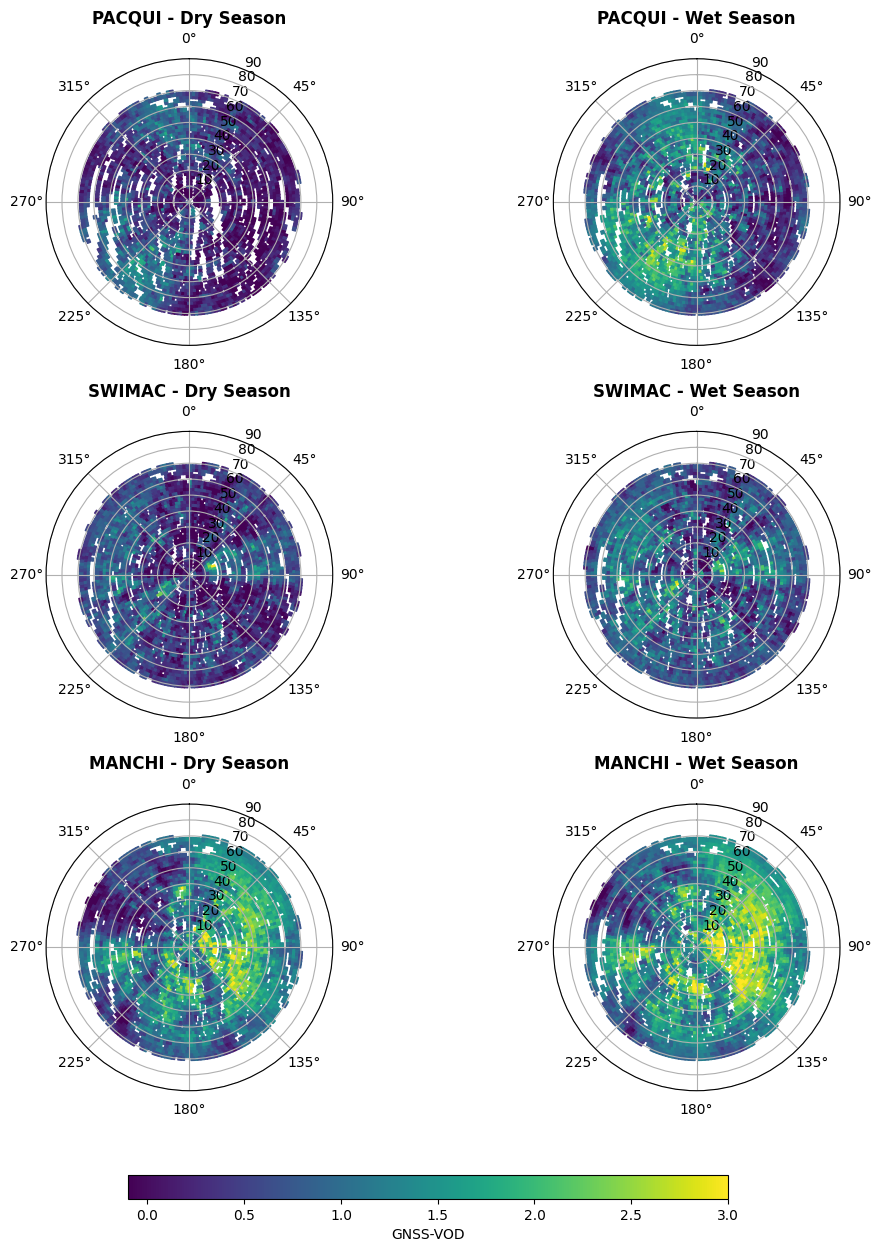

In [26]:
import os
from pathlib import Path

# Initialize hemispheric grid
hemi = gv.hemibuild(2)
patches = hemi.patches()

# Process each species and season
species = ['PACQUI', 'SWIMAC', 'MANCHI']
vod_processed = {}

for site_season, vod_data in vod_results.items():
    # Filter data to only include elevation >= 20 degrees
    vod_data = vod_data[vod_data['Elevation'] >= 20]
    
    # Classify vod into grid cells
    processed = hemi.add_CellID(vod_data).drop(columns=['Azimuth', 'Elevation'])
    # Get average value per grid cell
    vod_avg = processed.groupby(['CellID']).agg(['mean', 'std', 'count'])
    # Flatten the columns
    vod_avg.columns = ["_".join(x) for x in vod_avg.columns.to_flat_index()]
    vod_processed[site_season] = vod_avg

# Create figure with subplots for each species
fig, axes = plt.subplots(len(species), 2, figsize=(12, 4*len(species)), 
                         subplot_kw=dict(projection='polar'))

# Plot for each species
for i, species_name in enumerate(species):
    dry_data = vod_processed[f'{species_name}_dry']
    wet_data = vod_processed[f'{species_name}_wet']

    for j, (season_data, season_name) in enumerate([(dry_data, 'Dry Season'), 
                                                     (wet_data, 'Wet Season')]):
        # Filter to only show cells with more than 40 observations
        ivod_data = season_data['VOD1_mean'].where(season_data['VOD1_count']>40)
        # Associate mean values to patches
        ipatches = pd.concat([patches, ivod_data], join='inner', axis=1)

        # Create patch collection
        pc = PatchCollection(ipatches.Patches, array=ipatches['VOD1_mean'],
                             edgecolor='face', linewidth=1)
        pc.set_clim([-0.1, 3])

        # Add to subplot
        axes[i, j].add_collection(pc)
        axes[i, j].set_rlim([0, 90])
        axes[i, j].set_theta_zero_location("N")
        axes[i, j].set_theta_direction(-1)
        axes[i, j].set_title(f'{species_name} - {season_name}', fontweight='bold')

# Create a dedicated colorbar axis centered under the last row (MANCHI)
# Coordinates are [left, bottom, width, height] in figure fraction
cbar_left = 0.25
cbar_width = 0.5
cbar_bottom = 0.03
cbar_height = 0.02
cax = fig.add_axes([cbar_left, cbar_bottom, cbar_width, cbar_height])

# Use the last PatchCollection (pc) as the mappable for the colorbar
cbar = fig.colorbar(pc, cax=cax, orientation='horizontal')
cbar.set_label('GNSS-VOD')

# Ensure figures directory exists and save the figure
notebook_fig_dir = Path(os.path.expanduser('~'), 'Documents/github_repos/GNSS_ACG/PyNotebooks/figures')
notebook_fig_dir.mkdir(parents=True, exist_ok=True)
output_path = notebook_fig_dir / 'VOD_comparison_dry_wet_elevation_20.png'
fig.savefig(output_path, dpi=300, bbox_inches='tight')
print(f'Saved figure to: {output_path}')

# Adjust spacing between subplots to bring plots closer and leave room for the colorbar
plt.subplots_adjust(top=0.98, bottom=0.12, hspace=0.3)
plt.show()

#### Step 3: Calculate anomalies

Calculate VOD anomalies by subtracting the long-term baseline and aggregate into hourly time series

Saved VOD comparison figure to: /Users/ger/Documents/github_repos/GNSS_ACG/PyNotebooks/figures/VOD_comparison_with_without_baseline.png


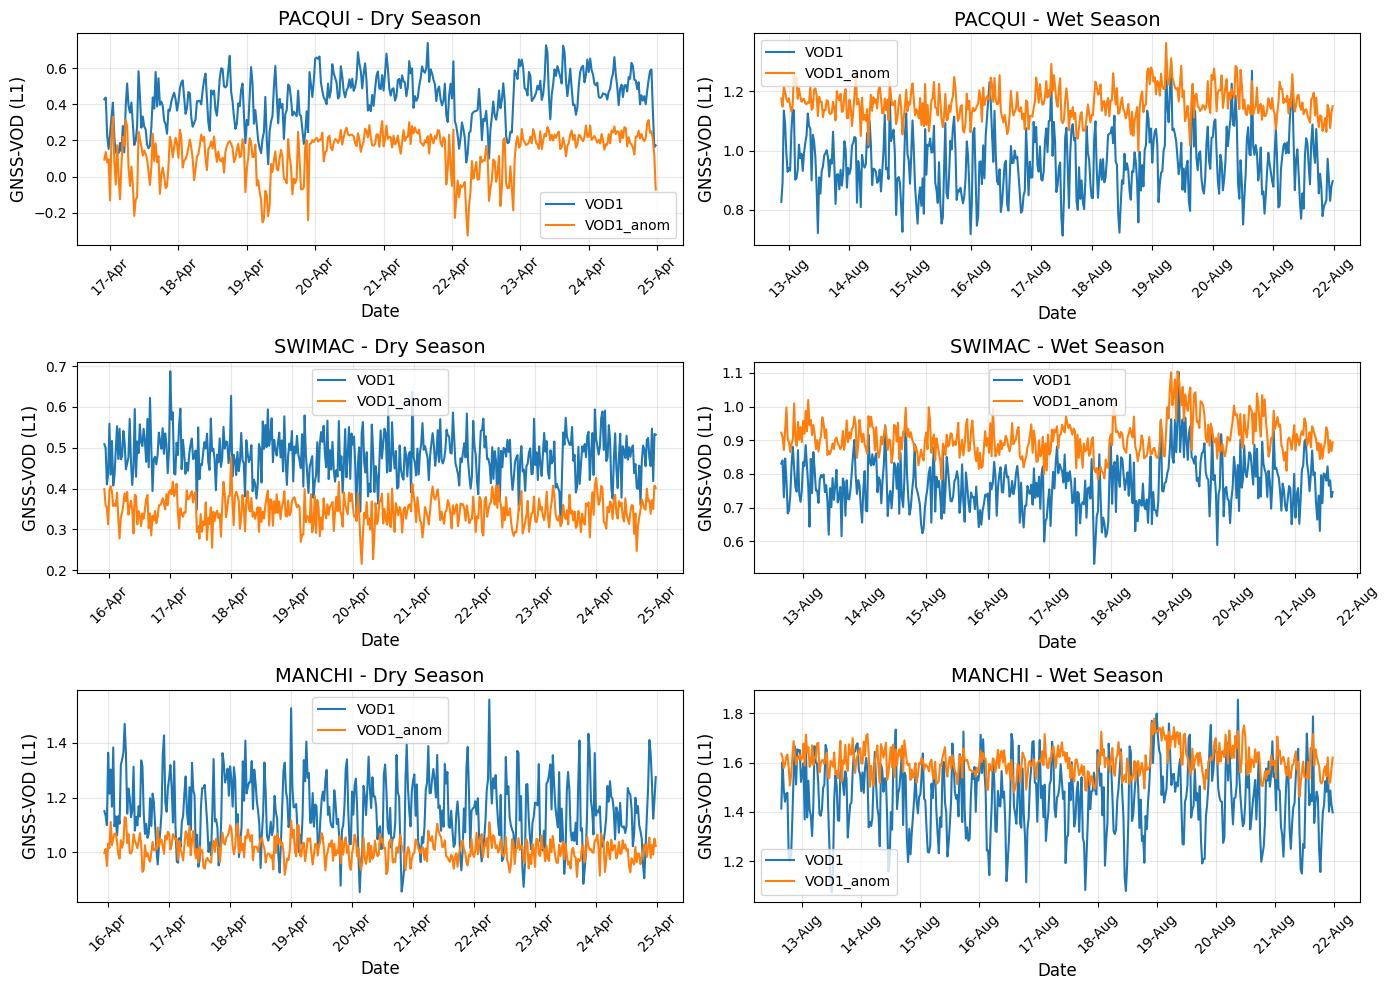

In [27]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path
import os

# Calculate time series variation in VOD for each season
period_vod = {}

# First, calculate long-term baseline (mean VOD per cell) for each species across all seasons
baseline_vod = {}
for species in ['PACQUI', 'SWIMAC', 'MANCHI']:
    # Combine dry and wet data for the species
    combined_data = pd.concat([vod_results[f'{species}_dry'], vod_results[f'{species}_wet']])
    # Add CellID (no elevation filter for baseline)
    combined_processed = hemi.add_CellID(combined_data).drop(columns=['Azimuth', 'Elevation'])
    # Compute long-term mean per cell
    combined_avg = combined_processed.groupby(['CellID']).agg(['mean', 'std', 'count'])
    combined_avg.columns = ["_".join(x) for x in combined_avg.columns.to_flat_index()]
    baseline_vod[species] = combined_avg

for site_season, vod_data in vod_results.items():
    # Extract species from site_season (e.g., 'PACQUI_dry' -> 'PACQUI')
    species = site_season.split('_')[0]
    
    # Classify vod into grid cells (keep Elevation for filtering later)
    vod = hemi.add_CellID(vod_data)
    vod_avg = baseline_vod[species]
    
    # Merge statistics with the original VOD measurements
    vod_anom = vod.join(vod_avg, on='CellID')
    
    # Calculate VOD anomalies
    vod_anom['VOD1_anom'] = vod_anom['VOD1'] - vod_anom['VOD1_mean']
    vod_anom['VOD7_anom'] = vod_anom['VOD7'] - vod_anom['VOD7_mean']
    
    # Now filter to only include elevation >= 20 degrees
    vod_anom = vod_anom[vod_anom['Elevation'] >= 20]
    
    # Drop Azimuth and Elevation as no longer needed
    vod_anom = vod_anom.drop(columns=['Azimuth', 'Elevation'])
    
    # Calculate time series by grouping into 30-minute intervals
    vod_ts = vod_anom.groupby(pd.Grouper(freq='30min', level='Epoch')).mean()
    
    # Add back the mean VOD so anomalies are centered around the mean, not zero
    vod_ts['VOD1_anom'] = vod_ts['VOD1_anom'] + vod_ts['VOD1'].mean()
    vod_ts['VOD7_anom'] = vod_ts['VOD7_anom'] + vod_ts['VOD7'].mean()
    
    # Store the time series
    period_vod[site_season] = vod_ts

# Plot comparison of VOD1 with and without baseline subtraction for each species and season
species = ['PACQUI', 'SWIMAC', 'MANCHI']
fig, axes = plt.subplots(len(species), 2, figsize=(14, 10))

vod_names = ['VOD1', 'VOD1_anom']

for i, species_name in enumerate(species):
    for j, season in enumerate(['dry', 'wet']):
        key = f'{species_name}_{season}'
        if key in period_vod:
            vod_ts = period_vod[key]
            ax = axes[i, j]
            
            for iname in vod_names:
                ax.plot(vod_ts.index, vod_ts[iname], label=iname)
            
            myFmt = mdates.DateFormatter('%d-%b')
            ax.xaxis.set_major_formatter(myFmt)
            ax.set_title(f'{species_name} - {season.title()} Season', fontsize=14)
            ax.set_xlabel('Date', fontsize=12)
            ax.set_ylabel('GNSS-VOD (L1)', fontsize=12)
            ax.grid(True, alpha=0.3)
            ax.tick_params(axis='x', rotation=45)
            ax.legend(loc='best')
        else:
            axes[i, j].text(0.5, 0.5, f'No data for {key}', ha='center', va='center', transform=axes[i, j].transAxes)

plt.tight_layout()

# Save the figure
notebook_fig_dir = Path(os.path.expanduser('~'), 'Documents/github_repos/GNSS_ACG/PyNotebooks/figures')
notebook_fig_dir.mkdir(parents=True, exist_ok=True)
output_path = notebook_fig_dir / 'VOD_comparison_with_without_baseline.png'
fig.savefig(output_path, dpi=300, bbox_inches='tight')
print(f'Saved VOD comparison figure to: {output_path}')

plt.show()

#### Step 4: Daily predawn and midday VOD

Extract daily pre-dawn (04:00–06:00 LT) and midday (12:00–14:00 LT) VOD values

Saved daily predawn vs midday VOD (clean signal) figure to: /Users/ger/Documents/github_repos/GNSS_ACG/PyNotebooks/figures/VOD_daily_predawn_vs_midday_clean.png


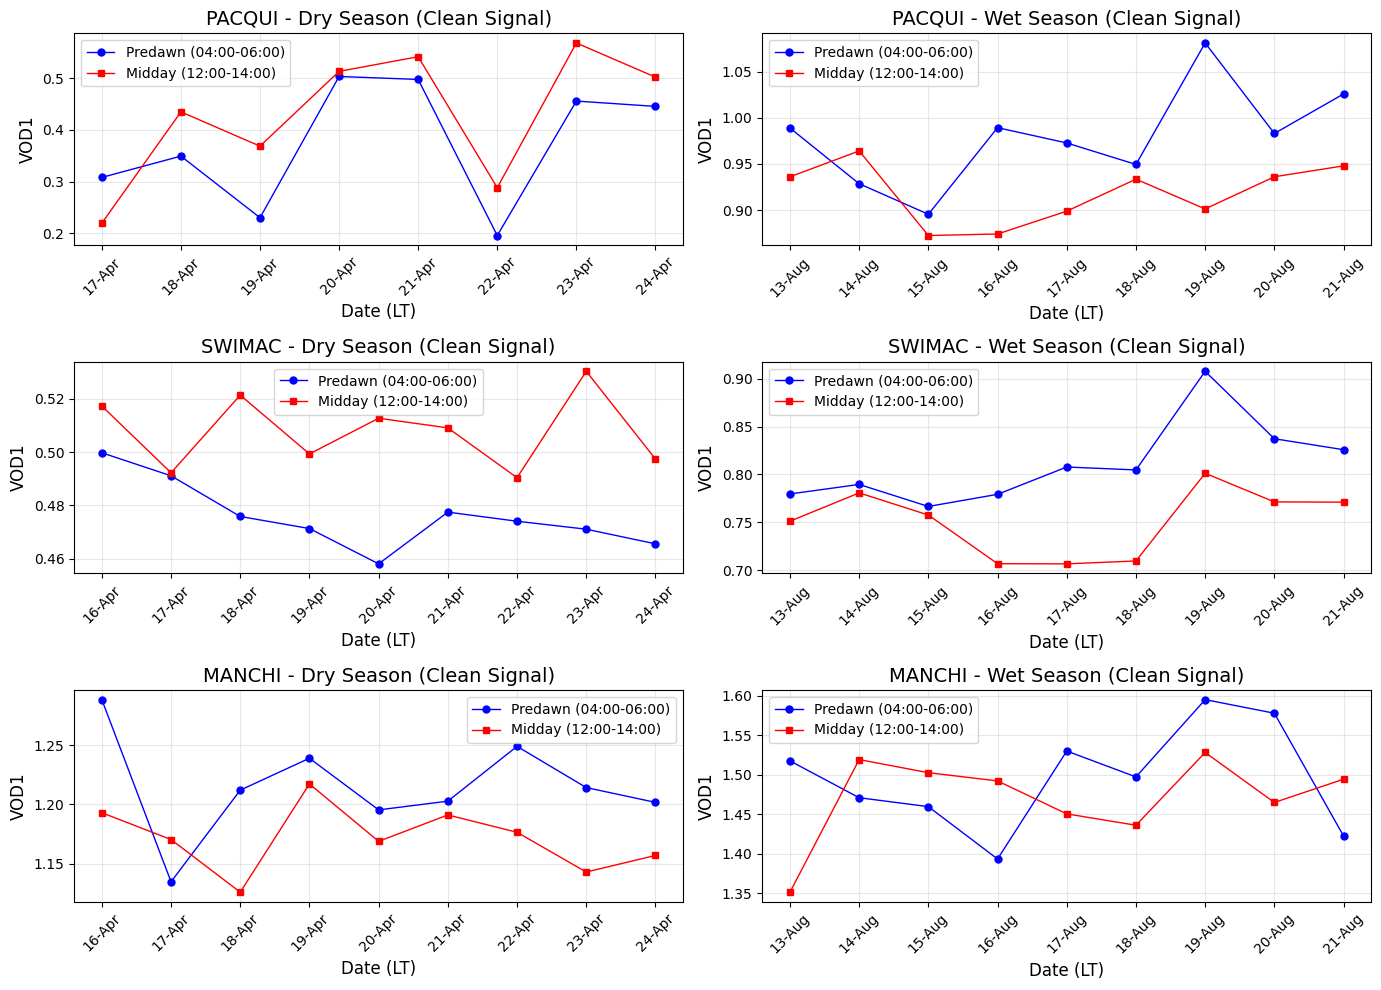

In [33]:
# Extract daily predawn and midday VOD from clean signal
# Predawn: 04:00-06:00 LT (hours 4, 5, 6)
# Midday: 12:00-14:00 LT (hours 12, 13, 14)

daily_predawn_clean = {}
daily_midday_clean = {}

for site_season, vod_hourly in period_vod.items():
    # Extract predawn hours (04:00-06:00)
    predawn_data = vod_hourly[vod_hourly.index.hour.isin([4, 5, 6])]
    daily_predawn_clean[site_season] = predawn_data.groupby(predawn_data.index.date).mean()
    
    # Extract midday hours (12:00-14:00)
    midday_data = vod_hourly[vod_hourly.index.hour.isin([12, 13, 14])]
    daily_midday_clean[site_season] = midday_data.groupby(midday_data.index.date).mean()

# Plot daily predawn vs midday VOD for each species and season (clean signal)
species = ['PACQUI', 'SWIMAC', 'MANCHI']
fig, axes = plt.subplots(len(species), 2, figsize=(14, 10))

for i, species_name in enumerate(species):
    for j, season in enumerate(['dry', 'wet']):
        key = f'{species_name}_{season}'
        if key in daily_predawn_clean:
            ax = axes[i, j]
            
            # Plot predawn and midday from clean signal
            ax.plot(daily_predawn_clean[key].index, daily_predawn_clean[key]['VOD1'], 'o-', 
                    color='blue', markersize=5, linewidth=1, label='Predawn (04:00-06:00)')
            ax.plot(daily_midday_clean[key].index, daily_midday_clean[key]['VOD1'], 's-', 
                    color='red', markersize=5, linewidth=1, label='Midday (12:00-14:00)')
            
            myFmt = mdates.DateFormatter('%d-%b')
            ax.xaxis.set_major_formatter(myFmt)
            ax.set_title(f'{species_name} - {season.title()} Season (Clean Signal)', fontsize=14)
            ax.set_xlabel('Date (LT)', fontsize=12)
            ax.set_ylabel('VOD1', fontsize=12)
            ax.grid(True, alpha=0.3)
            ax.tick_params(axis='x', rotation=45)
            ax.legend(loc='best')
        else:
            axes[i, j].text(0.5, 0.5, f'No data for {key}', ha='center', va='center', 
                           transform=axes[i, j].transAxes)

plt.tight_layout()

# Save the figure
notebook_fig_dir = Path(os.path.expanduser('~'), 'Documents/github_repos/GNSS_ACG/PyNotebooks/figures')
notebook_fig_dir.mkdir(parents=True, exist_ok=True)
output_path = notebook_fig_dir / 'VOD_daily_predawn_vs_midday_clean.png'
fig.savefig(output_path, dpi=300, bbox_inches='tight')
print(f'Saved daily predawn vs midday VOD (clean signal) figure to: {output_path}')

plt.show()

#### Step 5: Average diurnal cycle

Calculate the mean diurnal cycle by averaging VOD values across all days for each hour

Saved average diurnal cycle figure to: /Users/ger/Documents/github_repos/GNSS_ACG/PyNotebooks/figures/VOD_average_diurnal_cycle.png


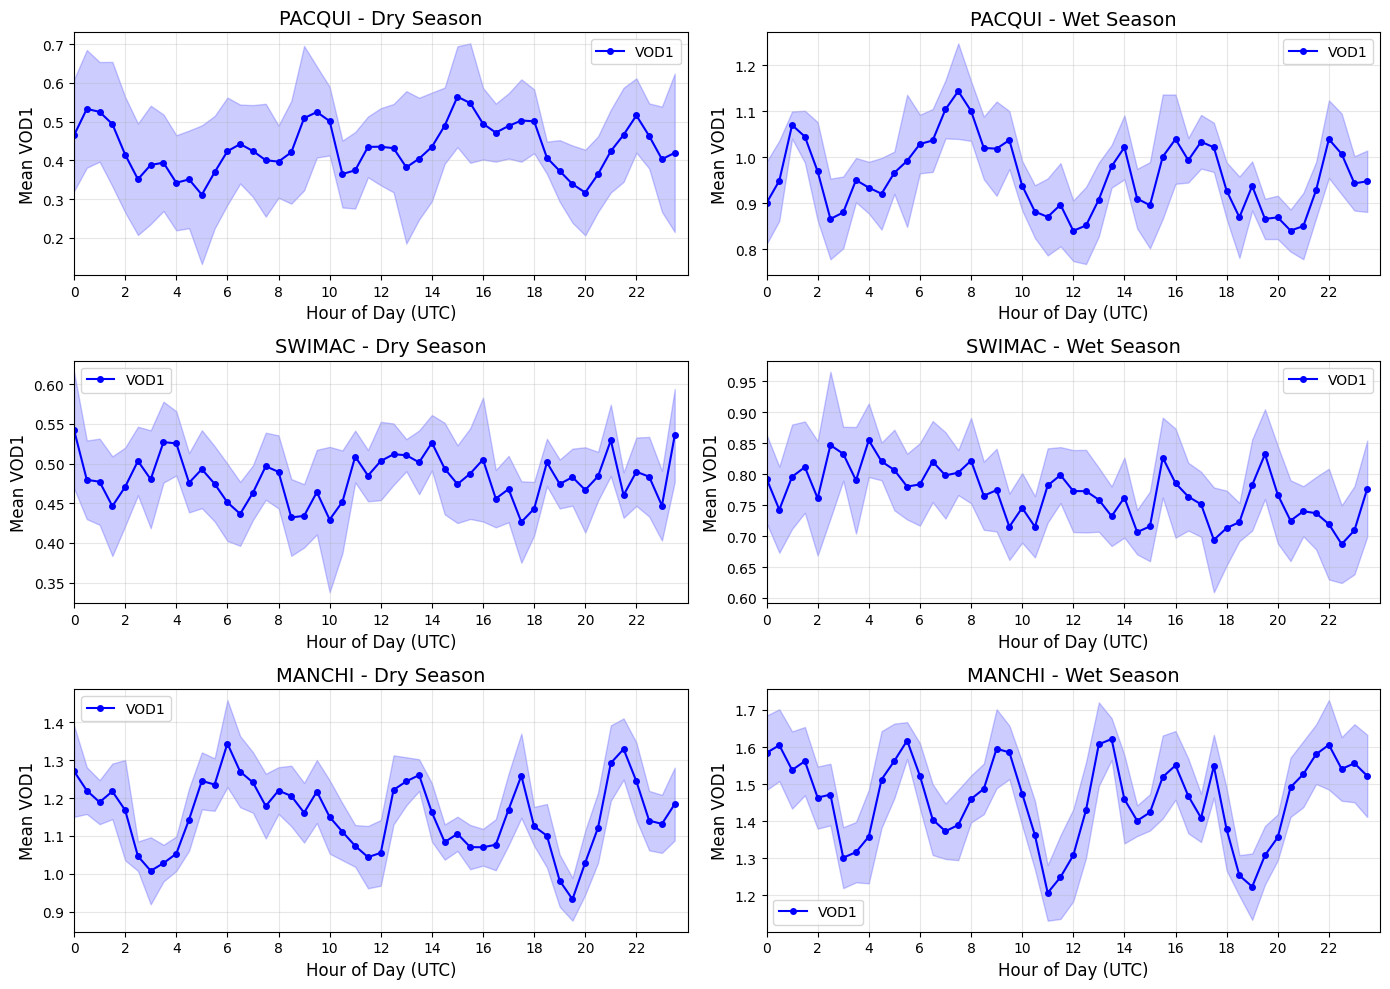


MANCHI_dry:
  VOD1 range: 0.93 - 1.34
  VOD1 amplitude: 0.41

MANCHI_wet:
  VOD1 range: 1.21 - 1.62
  VOD1 amplitude: 0.42

PACQUI_dry:
  VOD1 range: 0.31 - 0.56
  VOD1 amplitude: 0.25

PACQUI_wet:
  VOD1 range: 0.84 - 1.14
  VOD1 amplitude: 0.30

SWIMAC_dry:
  VOD1 range: 0.43 - 0.54
  VOD1 amplitude: 0.12

SWIMAC_wet:
  VOD1 range: 0.69 - 0.85
  VOD1 amplitude: 0.17


In [34]:
# Calculate average diurnal cycle from clean VOD signal at 15-minute resolution
diurnal_cycle = {}

for site_season, vod_hourly in period_vod.items():
    # Create 30-minute time-of-day bins (0-47 representing 00:00 to 23:30)
    time_of_day_30min = vod_hourly.index.hour * 2 + vod_hourly.index.minute // 30
    # Group by 30-minute intervals and calculate mean and std
    hourly_groups = vod_hourly.groupby(time_of_day_30min)
    diurnal_mean = hourly_groups[['VOD1', 'VOD7']].mean()
    diurnal_std = hourly_groups[['VOD1', 'VOD7']].std()
    
    diurnal_cycle[site_season] = {
        'mean': diurnal_mean,
        'std': diurnal_std,
        'count': hourly_groups.size()
    }

# Plot average diurnal cycle for each species and season
species = ['PACQUI', 'SWIMAC', 'MANCHI']
fig, axes = plt.subplots(len(species), 2, figsize=(14, 10))

for i, species_name in enumerate(species):
    for j, season in enumerate(['dry', 'wet']):
        key = f'{species_name}_{season}'
        if key in diurnal_cycle:
            ax = axes[i, j]
            
            # Extract mean and std for this species/season
            diurnal_data = diurnal_cycle[key]['mean']
            diurnal_err = diurnal_cycle[key]['std']
            time_bins = diurnal_data.index  # 0-47 representing 30-min intervals
            time_hours = time_bins / 2.0  # Convert to hours for plotting
            
            # Plot VOD1 with error band
            ax.plot(time_hours, diurnal_data['VOD1'], 'o-', color='blue', 
                   markersize=4, linewidth=1.5, label='VOD1')
            ax.fill_between(time_hours, 
                           diurnal_data['VOD1'] - diurnal_err['VOD1'],
                           diurnal_data['VOD1'] + diurnal_err['VOD1'],
                           color='blue', alpha=0.2)
            
            ax.set_title(f'{species_name} - {season.title()} Season', fontsize=14)
            ax.set_xlabel('Hour of Day (UTC)', fontsize=12)
            ax.set_ylabel('Mean VOD1', fontsize=12)
            ax.set_xticks(range(0, 24, 2))
            ax.set_xlim([0, 24])
            ax.grid(True, alpha=0.3)
            ax.legend(loc='best')
        else:
            axes[i, j].text(0.5, 0.5, f'No data for {key}', ha='center', va='center', 
                           transform=axes[i, j].transAxes)

plt.tight_layout()

# Save the figure
notebook_fig_dir = Path(os.path.expanduser('~'), 'Documents/github_repos/GNSS_ACG/PyNotebooks/figures')
notebook_fig_dir.mkdir(parents=True, exist_ok=True)
output_path = notebook_fig_dir / 'VOD_average_diurnal_cycle.png'
fig.savefig(output_path, dpi=300, bbox_inches='tight')
print(f'Saved average diurnal cycle figure to: {output_path}')

plt.show()

# Print summary statistics
for site_season in sorted(diurnal_cycle.keys()):
    print(f"\n{site_season}:")
    print(f"  VOD1 range: {diurnal_cycle[site_season]['mean']['VOD1'].min():.2f} - {diurnal_cycle[site_season]['mean']['VOD1'].max():.2f}")
    print(f"  VOD1 amplitude: {diurnal_cycle[site_season]['mean']['VOD1'].max() - diurnal_cycle[site_season]['mean']['VOD1'].min():.2f}")

#### Step 6: Compare clean vs anomaly diurnal cycles

Visualize the difference between clean VOD and anomaly-detrended diurnal cycles

Saved diurnal cycle comparison figure to: /Users/ger/Documents/github_repos/GNSS_ACG/PyNotebooks/figures/VOD_diurnal_cycle_comparison_clean_vs_anomaly.png


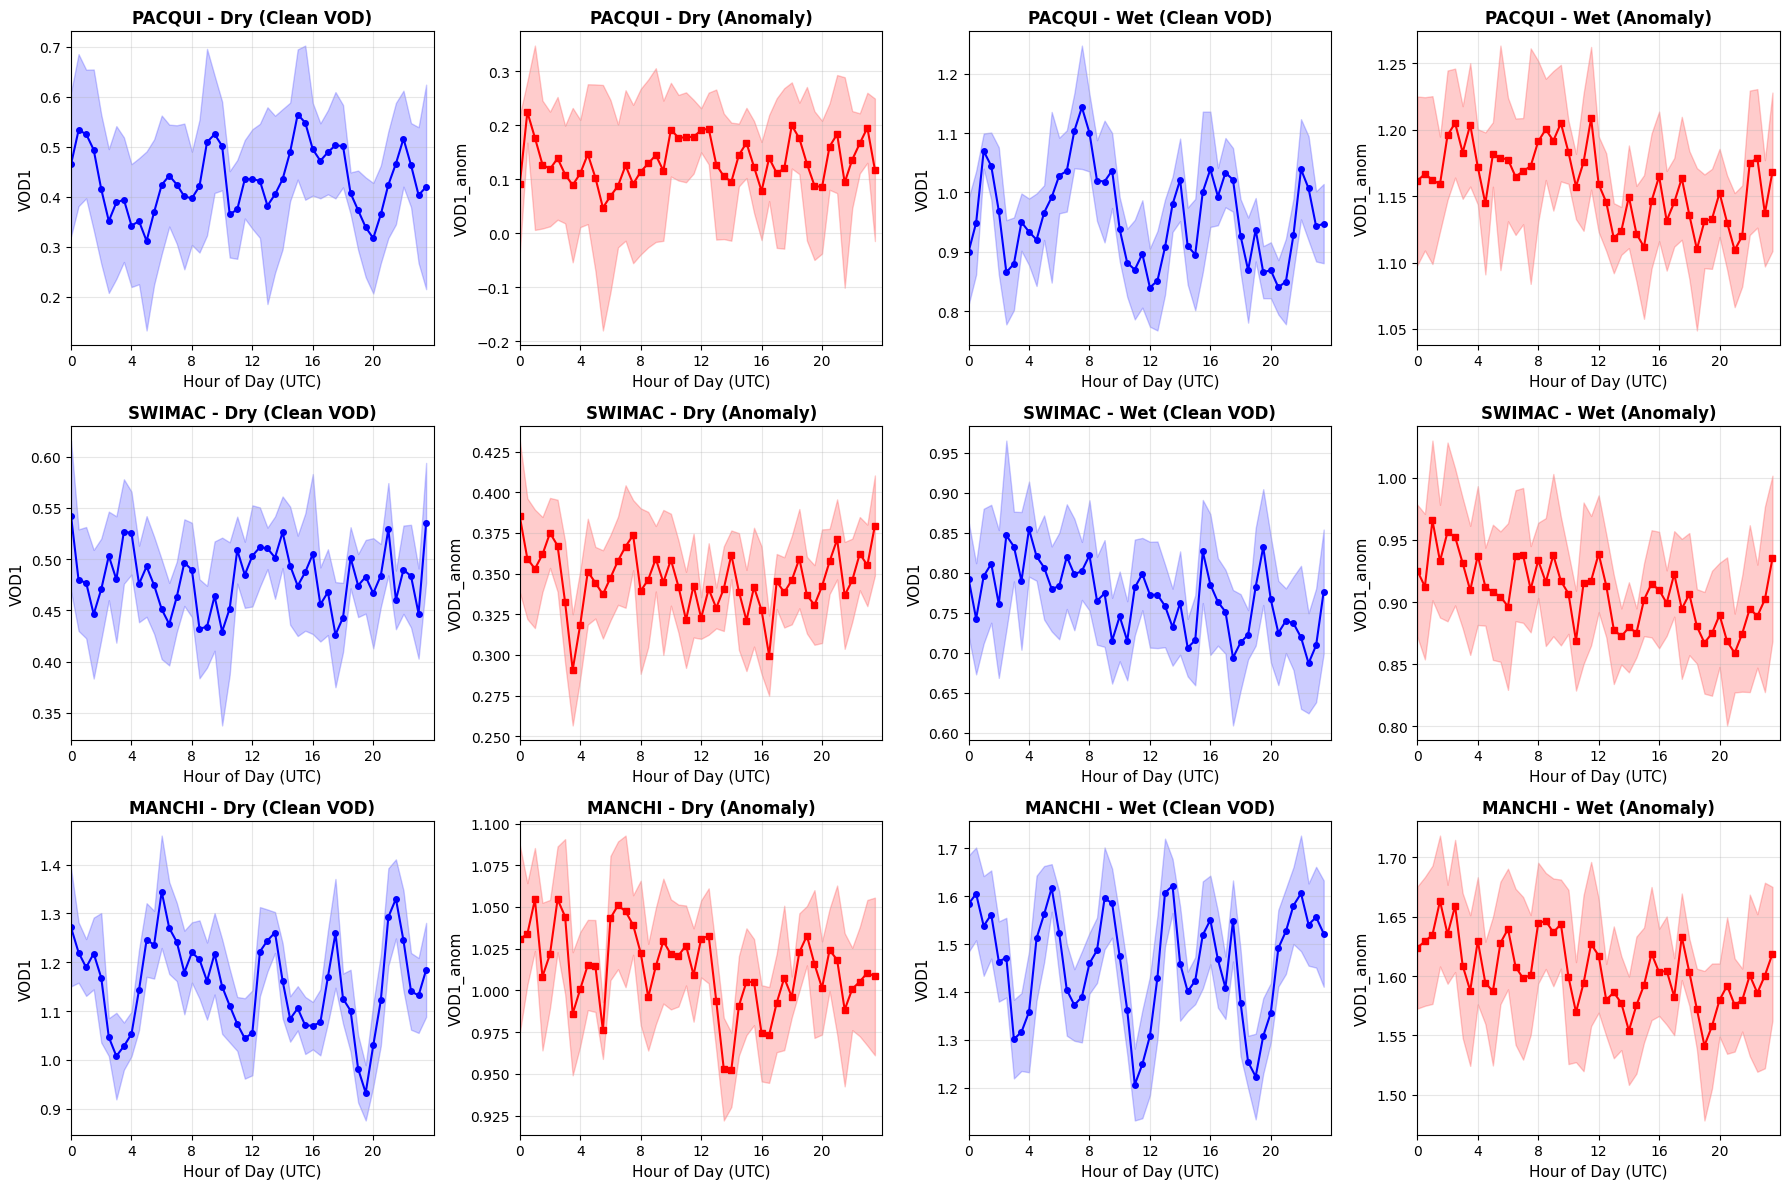


DIURNAL CYCLE COMPARISON: Clean VOD vs Anomaly

MANCHI_dry:
  Clean VOD1: range=0.93 - 1.34, amplitude=0.41
  Anomaly:    range=0.95 - 1.05, amplitude=0.10
  Difference in amplitude: 0.31

MANCHI_wet:
  Clean VOD1: range=1.21 - 1.62, amplitude=0.42
  Anomaly:    range=1.54 - 1.66, amplitude=0.12
  Difference in amplitude: 0.29

PACQUI_dry:
  Clean VOD1: range=0.31 - 0.56, amplitude=0.25
  Anomaly:    range=0.05 - 0.22, amplitude=0.18
  Difference in amplitude: 0.08

PACQUI_wet:
  Clean VOD1: range=0.84 - 1.14, amplitude=0.30
  Anomaly:    range=1.11 - 1.21, amplitude=0.10
  Difference in amplitude: 0.20

SWIMAC_dry:
  Clean VOD1: range=0.43 - 0.54, amplitude=0.12
  Anomaly:    range=0.29 - 0.39, amplitude=0.09
  Difference in amplitude: 0.02

SWIMAC_wet:
  Clean VOD1: range=0.69 - 0.85, amplitude=0.17
  Anomaly:    range=0.86 - 0.97, amplitude=0.11
  Difference in amplitude: 0.06


In [35]:
# Calculate diurnal cycle from anomaly data at 30-minute resolution
diurnal_cycle_anom = {}

for site_season, vod_ts_anom in period_vod.items():
    # Create 30-minute time-of-day bins (0-47 representing 00:00 to 23:30)
    time_of_day_30min = vod_ts_anom.index.hour * 2 + vod_ts_anom.index.minute // 30
    # Group by 30-minute intervals and calculate mean and std for anomaly
    hourly_groups = vod_ts_anom.groupby(time_of_day_30min)
    diurnal_mean_anom = hourly_groups[['VOD1_anom', 'VOD7_anom']].mean()
    diurnal_std_anom = hourly_groups[['VOD1_anom', 'VOD7_anom']].std()
    
    diurnal_cycle_anom[site_season] = {
        'mean': diurnal_mean_anom,
        'std': diurnal_std_anom,
        'count': hourly_groups.size()
    }

# Create comparison plots: Clean VOD vs Anomaly in separate panels (side-by-side)
# Layout: 3 species rows × 4 columns (dry_clean, dry_anom, wet_clean, wet_anom)
species = ['PACQUI', 'SWIMAC', 'MANCHI']
fig, axes = plt.subplots(len(species), 4, figsize=(18, 12))

for i, species_name in enumerate(species):
    for j, season in enumerate(['dry', 'wet']):
        key = f'{species_name}_{season}'
        if key in diurnal_cycle and key in diurnal_cycle_anom:
            # Extract data for clean VOD
            diurnal_clean = diurnal_cycle[key]['mean']
            diurnal_err_clean = diurnal_cycle[key]['std']
            time_bins = diurnal_clean.index  # 0-47 representing 30-min intervals
            time_hours = time_bins / 2.0  # Convert to hours for plotting
            
            # Extract data for anomaly
            diurnal_anom = diurnal_cycle_anom[key]['mean']
            diurnal_err_anom = diurnal_cycle_anom[key]['std']
            
            # Plot CLEAN VOD in left panel of the pair
            ax_clean = axes[i, j*2]
            ax_clean.plot(time_hours, diurnal_clean['VOD1'], 'o-', color='blue', 
                         markersize=4, linewidth=1.5)
            ax_clean.fill_between(time_hours, 
                                 diurnal_clean['VOD1'] - diurnal_err_clean['VOD1'],
                                 diurnal_clean['VOD1'] + diurnal_err_clean['VOD1'],
                                 color='blue', alpha=0.2)
            ax_clean.set_title(f'{species_name} - {season.title()} (Clean VOD)', fontsize=12, fontweight='bold')
            ax_clean.set_xlabel('Hour of Day (UTC)', fontsize=11)
            ax_clean.set_ylabel('VOD1', fontsize=11)
            ax_clean.set_xticks(range(0, 24, 4))
            ax_clean.set_xlim([0, 24])
            ax_clean.grid(True, alpha=0.3)
            
            # Plot ANOMALY in right panel of the pair
            ax_anom = axes[i, j*2 + 1]
            ax_anom.plot(time_hours, diurnal_anom['VOD1_anom'], 's-', color='red', 
                        markersize=4, linewidth=1.5)
            ax_anom.fill_between(time_hours, 
                                diurnal_anom['VOD1_anom'] - diurnal_err_anom['VOD1_anom'],
                                diurnal_anom['VOD1_anom'] + diurnal_err_anom['VOD1_anom'],
                                color='red', alpha=0.2)
            ax_anom.set_title(f'{species_name} - {season.title()} (Anomaly)', fontsize=12, fontweight='bold')
            ax_anom.set_xlabel('Hour of Day (UTC)', fontsize=11)
            ax_anom.set_ylabel('VOD1_anom', fontsize=11)
            ax_anom.set_xticks(range(0, 24, 4))
            ax_anom.set_xlim([0, 24])
            ax_anom.grid(True, alpha=0.3)

plt.tight_layout()

# Save the figure
notebook_fig_dir = Path(os.path.expanduser('~'), 'Documents/github_repos/GNSS_ACG/PyNotebooks/figures')
notebook_fig_dir.mkdir(parents=True, exist_ok=True)
output_path = notebook_fig_dir / 'VOD_diurnal_cycle_comparison_clean_vs_anomaly.png'
fig.savefig(output_path, dpi=300, bbox_inches='tight')
print(f'Saved diurnal cycle comparison figure to: {output_path}')

plt.show()

# Print comparison summary
print("\n" + "="*70)
print("DIURNAL CYCLE COMPARISON: Clean VOD vs Anomaly")
print("="*70)
for site_season in sorted(diurnal_cycle.keys()):
    clean_amp = diurnal_cycle[site_season]['mean']['VOD1'].max() - diurnal_cycle[site_season]['mean']['VOD1'].min()
    anom_amp = diurnal_cycle_anom[site_season]['mean']['VOD1_anom'].max() - diurnal_cycle_anom[site_season]['mean']['VOD1_anom'].min()
    clean_range = f"{diurnal_cycle[site_season]['mean']['VOD1'].min():.2f} - {diurnal_cycle[site_season]['mean']['VOD1'].max():.2f}"
    anom_range = f"{diurnal_cycle_anom[site_season]['mean']['VOD1_anom'].min():.2f} - {diurnal_cycle_anom[site_season]['mean']['VOD1_anom'].max():.2f}"
    
    print(f"\n{site_season}:")
    print(f"  Clean VOD1: range={clean_range}, amplitude={clean_amp:.2f}")
    print(f"  Anomaly:    range={anom_range}, amplitude={anom_amp:.2f}")
    print(f"  Difference in amplitude: {abs(clean_amp - anom_amp):.2f}")

### Step 7: Plot only anomaly detrended

Visualize the difference between clean VOD and anomaly-detrended diurnal cycles

/var/folders/51/nh4w5ktd20v0jyx9rlm3cnq80000gn/T/ipykernel_33343/1814122834.py:43: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([round(tick, 1) for tick in ax.get_yticks()], fontsize=14)
/var/folders/51/nh4w5ktd20v0jyx9rlm3cnq80000gn/T/ipykernel_33343/1814122834.py:43: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([round(tick, 1) for tick in ax.get_yticks()], fontsize=14)
/var/folders/51/nh4w5ktd20v0jyx9rlm3cnq80000gn/T/ipykernel_33343/1814122834.py:43: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([round(tick, 1) for tick in ax.get_yticks()], fontsize=14)
/var/folders/51/nh4w5ktd20v0jyx9rlm3cnq80000gn/T/ipykernel_33343/1814122834.py:43: UserWarning: set_ticklabels() should only be

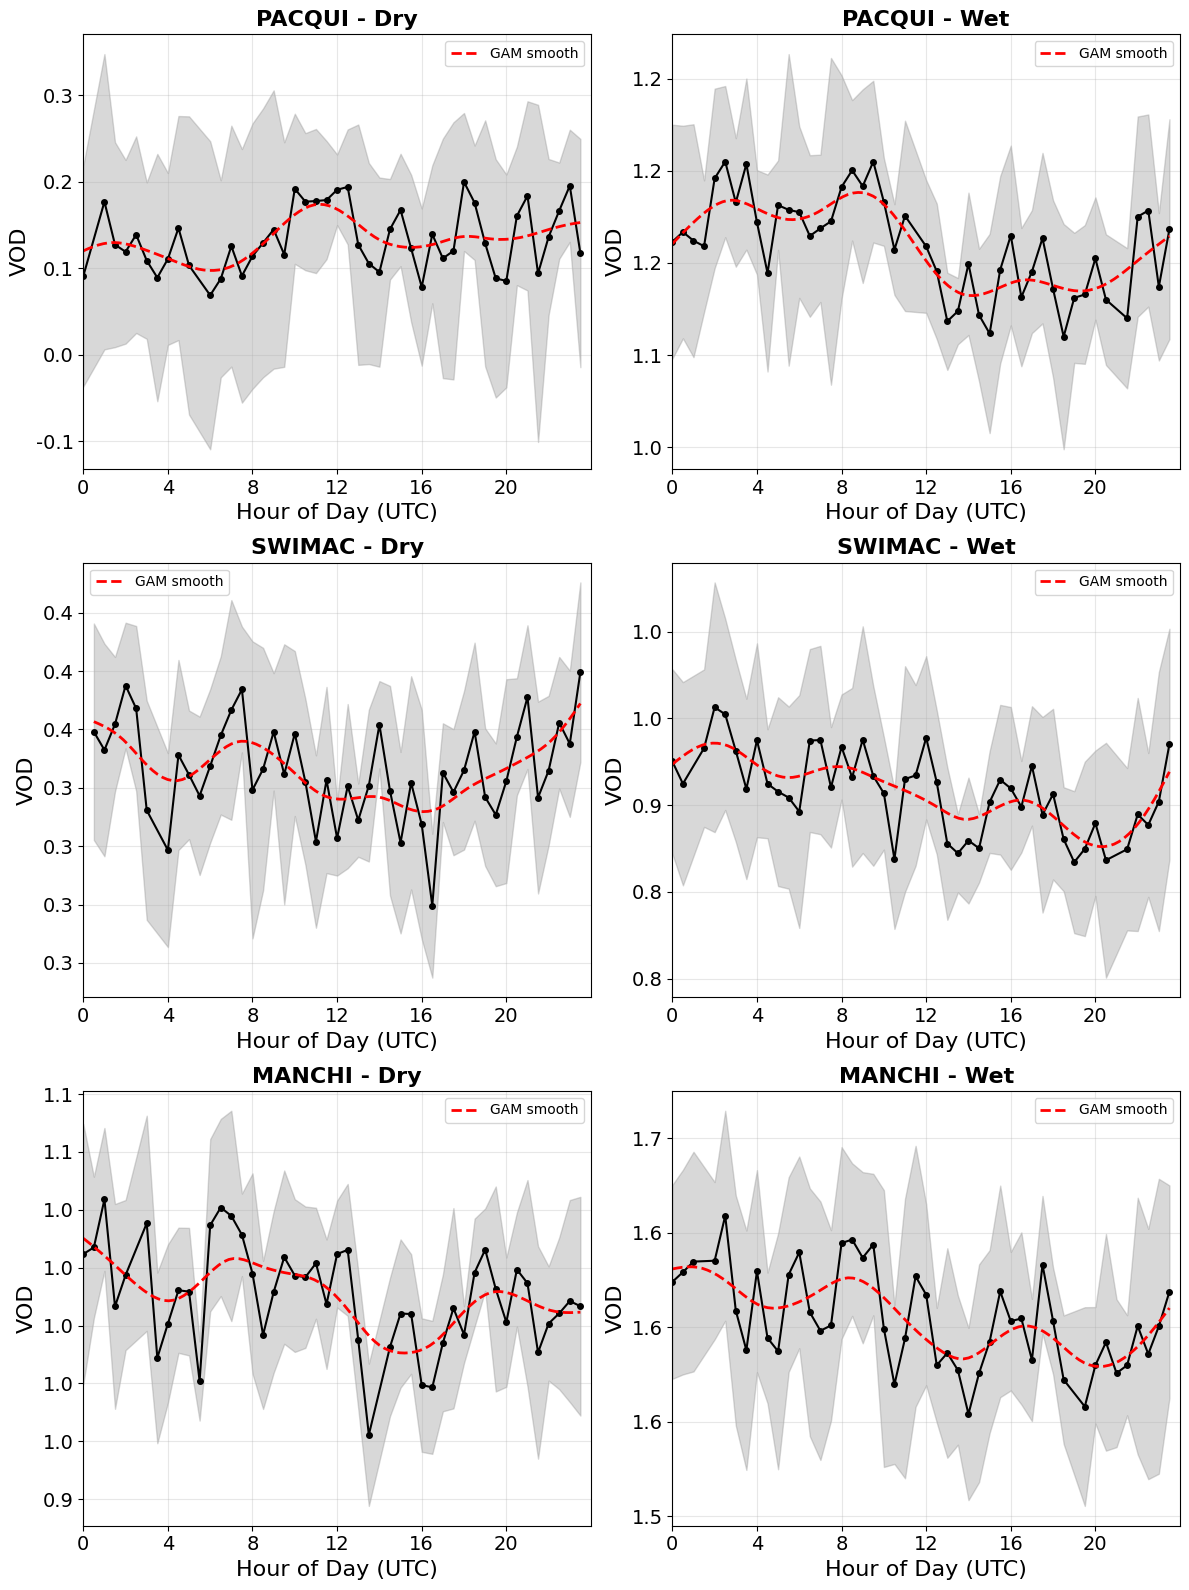

In [73]:
# Plot diurnal cycle from anomaly data at 30-minute resolution with quantile filtering and GAM smoothing (red dashed line)
from pygam import LinearGAM, s
species = ['PACQUI', 'SWIMAC', 'MANCHI']
fig, axes = plt.subplots(len(species), 2, figsize=(12, 16))

for i, species_name in enumerate(species):
    for j, season in enumerate(['dry', 'wet']):
        key = f'{species_name}_{season}'
        if key in diurnal_cycle_anom:
            diurnal_anom = diurnal_cycle_anom[key]['mean']
            diurnal_err_anom = diurnal_cycle_anom[key]['std']
            time_bins = diurnal_anom.index
            time_hours = time_bins / 2.0

            # Quantile filtering for VOD1_anom
            q_low = diurnal_anom['VOD1_anom'].quantile(0.01)
            q_high = diurnal_anom['VOD1_anom'].quantile(0.99)
            mask = (diurnal_anom['VOD1_anom'] >= q_low) & (diurnal_anom['VOD1_anom'] <= q_high)

            ax = axes[i, j]
            # Plot ribbon (error band) in grey
            ax.fill_between(time_hours[mask],
                            diurnal_anom['VOD1_anom'][mask] - diurnal_err_anom['VOD1_anom'][mask],
                            diurnal_anom['VOD1_anom'][mask] + diurnal_err_anom['VOD1_anom'][mask],
                            color='grey', alpha=0.3)
            # Plot points and lines in black
            ax.plot(time_hours[mask], diurnal_anom['VOD1_anom'][mask], 'o-', color='black', markersize=4, linewidth=1.5)

            # Add GAM smooth model (red dashed line)
            X = time_hours[mask].values.reshape(-1, 1)
            y = diurnal_anom['VOD1_anom'][mask].values
            if len(X) > 5:
                gam = LinearGAM(s(0)).fit(X, y)
                XX = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
                y_pred = gam.predict(XX)
                ax.plot(XX.flatten(), y_pred, color='red', linestyle='--', linewidth=2, label='GAM smooth')

            ax.set_title(f'{species_name} - {season.title()}', fontsize=16, fontweight='bold')
            ax.set_xlabel('Hour of Day (UTC)', fontsize=16)
            ax.set_ylabel('VOD', fontsize=16)
            ax.set_xticks(range(0, 24, 4))
            ax.set_xticklabels(range(0, 24, 4), fontsize=14)
            ax.set_yticklabels([round(tick, 1) for tick in ax.get_yticks()], fontsize=14)
            ax.set_xlim([0, 24])
            ax.grid(True, alpha=0.3)
            ax.legend()
        else:
            axes[i, j].text(0.5, 0.5, f'No data for {key}', ha='center', va='center', transform=axes[i, j].transAxes)

plt.tight_layout()
plt.show()

/var/folders/51/nh4w5ktd20v0jyx9rlm3cnq80000gn/T/ipykernel_33343/1571865973.py:50: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot(data, labels=labels, patch_artist=True,
/var/folders/51/nh4w5ktd20v0jyx9rlm3cnq80000gn/T/ipykernel_33343/1571865973.py:57: UserWarning: First parameter to grid() is false, but line properties are supplied. The grid will be enabled.
  ax.grid(False, alpha=0.3)
/var/folders/51/nh4w5ktd20v0jyx9rlm3cnq80000gn/T/ipykernel_33343/1571865973.py:50: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot(data, labels=labels, patch_artist=True,
/var/folders/51/nh4w5ktd20v0jyx9rlm3cnq80000gn/T/ipykernel_33343/1571865973.py:57: UserWarning: First parameter to grid() is false, but line properties are su

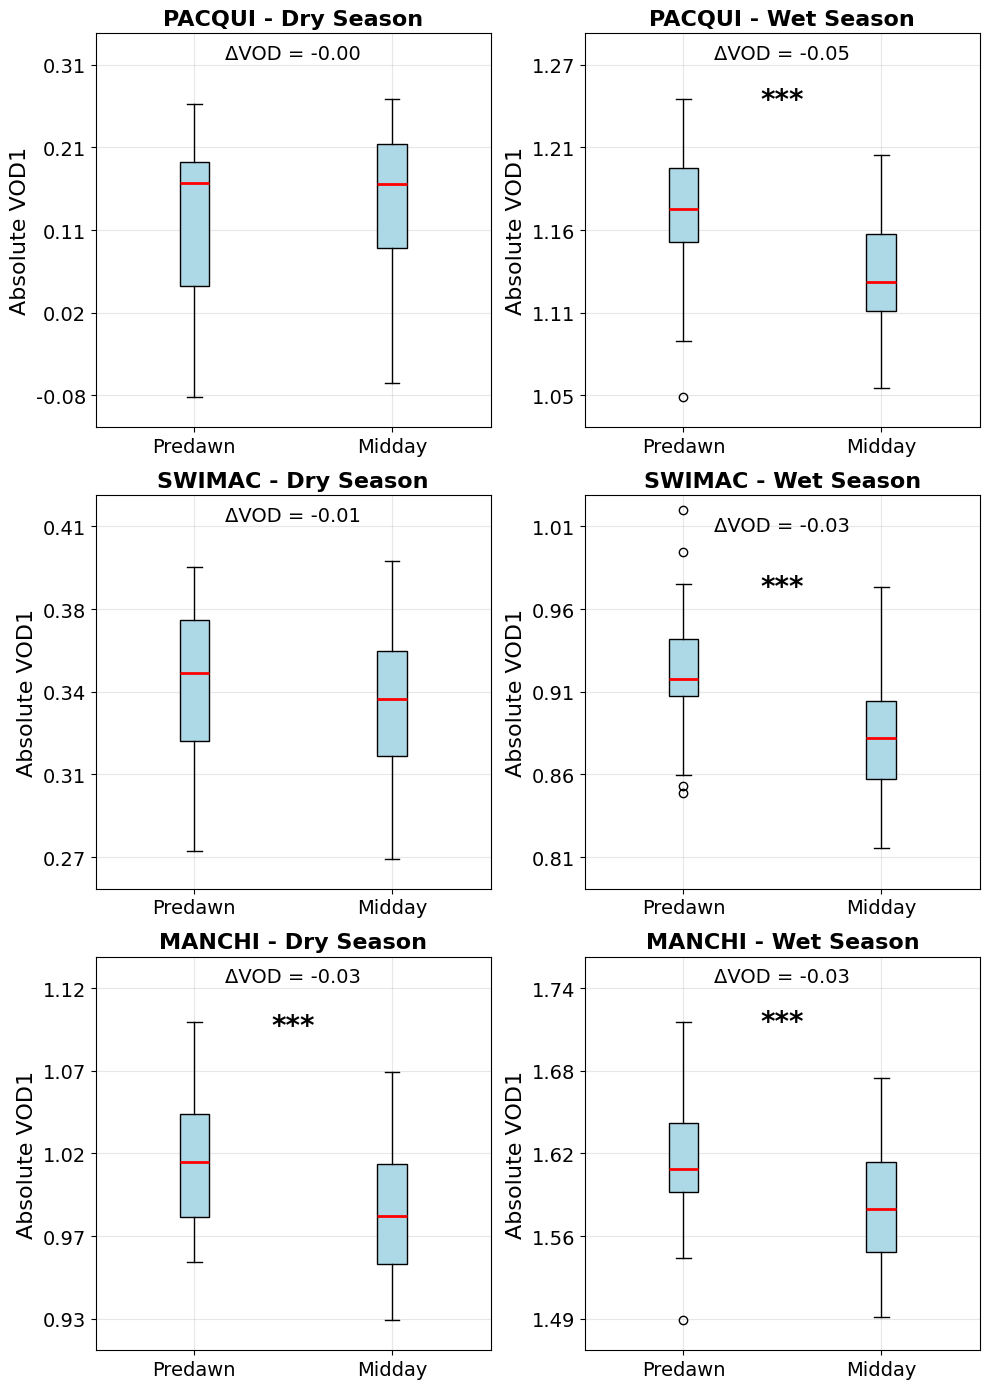

In [104]:
# Boxplots of absolute VOD1 values at predawn (2–4:30 am) vs midday (12:30 pm–3 pm) for each species and season, with t-test significance asterisks and delta VOD annotation centered between the two boxplots. Y axis is expanded to ensure annotation fits and does not overlap boxes. Tick labels are explicitly set for all plots. Only 5 y-ticks are shown per plot, avoiding ticks at the exact min/max (corners).
from scipy.stats import ttest_ind
import numpy as np
species = ['PACQUI', 'SWIMAC', 'MANCHI']
fig, axes = plt.subplots(len(species), 2, figsize=(10, 14))  # Increased height

def get_inner_ticks(ylim_bottom, ylim_top, n=5):
    # Avoid ticks at the exact min/max by shrinking the range a bit
    pad = 0.08 * (ylim_top - ylim_bottom)
    inner_min = ylim_bottom + pad
    inner_max = ylim_top - pad
    return np.linspace(inner_min, inner_max, n)

for i, species_name in enumerate(species):
    for j, season in enumerate(['dry', 'wet']):
        key = f'{species_name}_{season}'
        if key in period_vod:
            vod_hourly = period_vod[key]
            # Extract predawn: 2:00–4:30 am (hours 2, 3, 4:00, 4:30)
            predawn_mask = ((vod_hourly.index.hour == 2) & (vod_hourly.index.minute == 0)) | \
                           ((vod_hourly.index.hour == 3) & (vod_hourly.index.minute == 0)) | \
                           ((vod_hourly.index.hour == 4) & (vod_hourly.index.minute.isin([0, 30])))
            predawn_vod = vod_hourly[predawn_mask]['VOD1_anom']

            # Extract midday: 12:30–15:00 (12:30 pm to 3 pm)
            midday_mask = ((vod_hourly.index.hour == 12) & (vod_hourly.index.minute == 30)) | \
                          ((vod_hourly.index.hour == 13) & (vod_hourly.index.minute.isin([0, 30]))) | \
                          ((vod_hourly.index.hour == 14) & (vod_hourly.index.minute.isin([0, 30]))) | \
                          ((vod_hourly.index.hour == 15) & (vod_hourly.index.minute == 0))
            midday_vod = vod_hourly[midday_mask]['VOD1_anom']

            # Combine for quantile calculation
            combined = pd.concat([predawn_vod, midday_vod])
            q_low = combined.quantile(0.01)
            q_high = combined.quantile(0.99)

            # Create mask for each
            mask_predawn = (predawn_vod >= q_low) & (predawn_vod <= q_high)
            mask_midday = (midday_vod >= q_low) & (midday_vod <= q_high)

            # Filtered values
            filtered_predawn = predawn_vod[mask_predawn].dropna()
            filtered_midday = midday_vod[mask_midday].dropna()

            # Prepare data for boxplot
            data = [filtered_predawn, filtered_midday]
            labels = ['Predawn', 'Midday']

            ax = axes[i, j]
            box = ax.boxplot(data, labels=labels, patch_artist=True,
                            boxprops=dict(facecolor='lightblue'),
                            medianprops=dict(color='red', linewidth=2))
            ax.set_title(f'{species_name} - {season.title()} Season', fontsize=16, fontweight='bold')
            ax.set_ylabel('Absolute VOD1', fontsize=16)
            ax.set_xticks([1, 2])
            ax.set_xticklabels(labels, fontsize=14)
            ax.grid(False, alpha=0.3)

            # Median delta VOD annotation and t-test asterisks
            if len(filtered_predawn) > 1 and len(filtered_midday) > 1:
                median_predawn = filtered_predawn.median()
                median_midday = filtered_midday.median()
                delta_vod = median_midday - median_predawn
                t_stat, p_val = ttest_ind(filtered_predawn, filtered_midday, equal_var=False)
                # Determine significance level and asterisks
                if p_val < 0.001:
                    stars = '***'
                elif p_val < 0.01:
                    stars = '**'
                elif p_val < 0.05:
                    stars = '*'
                else:
                    stars = 'NS'  # Not significant

                # Center between the two boxplots (x=1.5)
                x_center = 1.5

                # Get the highest upper whisker (for space above both boxes)
                y_predawn_upper = box['whiskers'][1].get_ydata()[1] if 'whiskers' in box and len(box['whiskers']) > 1 else filtered_predawn.max()
                y_midday_upper = box['whiskers'][3].get_ydata()[1] if 'whiskers' in box and len(box['whiskers']) > 3 else filtered_midday.max()
                y_upper = max(y_predawn_upper, y_midday_upper)
                y_box_max = max([d.max() if len(d) > 0 else 0 for d in data])
                y_box_min = min([d.min() if len(d) > 0 else 0 for d in data])
                # Expand y axis by a fixed fraction above the highest box/whisker
                h = 0.1 * (y_box_max - y_box_min) if (y_box_max - y_box_min) > 0 else 1
                y_asterisk = y_upper
                if stars != 'NS':
                    ax.text(x_center, y_asterisk-0.01, stars, ha='center', va='bottom', color='black', fontsize=20, fontweight='bold')
                # Center delta VOD above the asterisk (even if not significant)
                ax.text(x_center, y_asterisk + 1.2*h, f"ΔVOD = {delta_vod:.2f}", ha='center', va='bottom', color='black', fontsize=14)
                # Set y-limits to ensure annotation and asterisks are visible and do not overlap boxes
                ylim_bottom = y_box_min - 0.1 * (y_box_max - y_box_min)
                ylim_top = y_asterisk + 2.2 * h
                ax.set_ylim([ylim_bottom, ylim_top])
                # Set 5 y-ticks, avoiding corners
                yticks = get_inner_ticks(ylim_bottom, ylim_top, 5)
                ax.set_yticks(yticks)
                ax.set_yticklabels([f'{tick:.2f}' for tick in yticks], fontsize=14)
            else:
                # Median annotation if only one group has data
                if len(filtered_predawn) > 0 and len(filtered_midday) > 0:
                    median_predawn = filtered_predawn.median()
                    median_midday = filtered_midday.median()
                    delta_vod = median_midday - median_predawn
                    y_box_max = max([d.max() if len(d) > 0 else 0 for d in data])
                    y_box_min = min([d.min() if len(d) > 0 else 0 for d in data])
                    y_annot = y_box_max + 0.12 * (y_box_max - y_box_min)
                    ax.text(1.5, y_annot, f"ΔVOD = {delta_vod:.2f}", ha='center', va='bottom', color='black', fontsize=14)
                # Set y-limits to ensure enough space above boxes
                y_max = max([d.max() if len(d) > 0 else 0 for d in data])
                y_min = min([d.min() if len(d) > 0 else 0 for d in data])
                ylim_bottom = y_min - 0.1 * (y_max - y_min)
                ylim_top = y_max + 0.25 * (y_max - y_min)
                ax.set_ylim([ylim_bottom, ylim_top])
                yticks = get_inner_ticks(ylim_bottom, ylim_top, 5)
                ax.set_yticks(yticks)
                ax.set_yticklabels([f'{tick:.2f}' for tick in yticks], fontsize=14)
        else:
            axes[i, j].set_xticks([1, 2])
            axes[i, j].set_xticklabels(labels, fontsize=14)
            # Set 5 y-ticks for empty plots as well, avoiding corners
            y_ticks = axes[i, j].get_yticks()
            if len(y_ticks) > 1:
                yticks = get_inner_ticks(y_ticks[0], y_ticks[-1], 5)
                axes[i, j].set_yticks(yticks)
                axes[i, j].set_yticklabels([f'{tick:.2f}' for tick in yticks], fontsize=14)
            axes[i, j].text(0.5, 0.5, f'No data for {key}', ha='center', va='center', transform=axes[i, j].transAxes)

plt.tight_layout()
plt.show()

In [86]:
# Perform t-test comparing absolute VOD1 values at predawn (1 am–4 am) vs midday (12:30 pm–3 pm) for each species and season
from scipy.stats import ttest_ind
species = ['PACQUI', 'SWIMAC', 'MANCHI']

results = []
for species_name in species:
    for season in ['dry', 'wet']:
        key = f'{species_name}_{season}'
        if key in period_vod:
            vod_hourly = period_vod[key]
            # Extract predawn: 1:00–4:00 am (hours 1, 2, 3, 4)
            predawn_mask = ((vod_hourly.index.hour == 2) & (vod_hourly.index.minute == 0)) | \
                           ((vod_hourly.index.hour == 3) & (vod_hourly.index.minute == 0)) | \
                           ((vod_hourly.index.hour == 4) & (vod_hourly.index.minute == 0)) | \
                           ((vod_hourly.index.hour == 4) & (vod_hourly.index.minute == 30))
            predawn_vod = vod_hourly[predawn_mask]['VOD1_anom']

            # Extract midday: 12:30–15:00 (12:30 pm to 3 pm)
            midday_mask = ((vod_hourly.index.hour == 12) & (vod_hourly.index.minute == 30)) | \
                          ((vod_hourly.index.hour == 13) & (vod_hourly.index.minute.isin([0, 30]))) | \
                          ((vod_hourly.index.hour == 14) & (vod_hourly.index.minute.isin([0, 30]))) | \
                          ((vod_hourly.index.hour == 15) & (vod_hourly.index.minute == 0))
            midday_vod = vod_hourly[midday_mask]['VOD1_anom']

            # Combine for quantile calculation
            combined = pd.concat([predawn_vod, midday_vod])
            q_low = combined.quantile(0.01)
            q_high = combined.quantile(0.99)

            # Create mask for each
            mask_predawn = (predawn_vod >= q_low) & (predawn_vod <= q_high)
            mask_midday = (midday_vod >= q_low) & (midday_vod <= q_high)

            # Filtered values
            filtered_predawn = predawn_vod[mask_predawn].dropna()
            filtered_midday = midday_vod[mask_midday].dropna()

            # Prepare data for boxplot
            data = [filtered_predawn, filtered_midday]
            labels = ['Predawn (1–4 am)', 'Midday (12:30–3 pm)']

            # Perform t-test (independent samples)
            if len(filtered_predawn) > 1 and len(filtered_midday) > 1:
                t_stat, p_val = ttest_ind(filtered_predawn, filtered_midday, equal_var=False)
                results.append((species_name, season, t_stat, p_val, len(filtered_predawn), len(filtered_midday)))
            else:
                results.append((species_name, season, None, None, len(filtered_predawn), len(filtered_midday)))

# Display results
print('T-test results for absolute VOD1 values at predawn (1–4 am) vs midday (12:30–3 pm):')
print('Species\tSeason\tT-stat\tP-value\tN_predawn\tN_midday')
for r in results:
    print(f'{r[0]}\t{r[1]}\t{r[2]}\t{r[3]}\t{r[4]}\t{r[5]}')

T-test results for absolute VOD1 values at predawn (1–4 am) vs midday (12:30–3 pm):
Species	Season	T-stat	P-value	N_predawn	N_midday
PACQUI	dry	-0.9269861861143998	0.3576158056675623	32	46
PACQUI	wet	4.688875971085083	1.5520877304171208e-05	35	53
SWIMAC	dry	0.8534354775075995	0.39683229312215756	34	54
SWIMAC	wet	4.504965884284998	3.271913454161838e-05	35	52
MANCHI	dry	3.5998692807779142	0.0005578768896601674	35	53
MANCHI	wet	3.449144611560309	0.0009547363268554829	35	53
